# Hyperband Search for Tiny Shakespeare

Goal: test whether Hyperband-style search beats manual autoresearch sweep under same fixed compute budget.

In [1]:
!rm -rf /content/comp560-niloy

In [2]:
import os
import sys
import subprocess
import importlib.util
from pathlib import Path

REQUIRED_MODULES = ["numpy", "torch", "matplotlib"]
missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing Python packages: " + ", ".join(missing) + "\n"
        + "Install first, e.g. pip install numpy torch matplotlib notebook"
    )

import torch

ROOT = Path("/content/comp560-niloy/autoresearch-tinyshakespeare")
REPO = ROOT.parent

if not ROOT.exists():
    print("Cloning repo into /content ...")
    subprocess.run(
        ["git", "clone", "https://github.com/niloy-saha-123/comp560-niloy.git", str(REPO)],
        check=True,
    )

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("cwd:", Path.cwd().resolve())
print("root:", ROOT)
print(sys.executable)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

for required in ["prepare.py", "train.py", "hyperband_utils.py", "compare_seeds.py", "compare_budgets.py"]:
    print(required, (ROOT / required).exists())

generated = ["input.txt", "meta.json", "eval_batches.npz"]
missing_generated = [name for name in generated if not (ROOT / name).exists()]
print("generated status:", {name: (ROOT / name).exists() for name in generated})

if missing_generated:
    print("Running prepare.py because missing:", missing_generated)
    subprocess.run([sys.executable, str(ROOT / "prepare.py")], cwd=ROOT, check=True)
    print("prepare.py done")


Cloning repo into /content ...
cwd: /content/comp560-niloy/autoresearch-tinyshakespeare
root: /content/comp560-niloy/autoresearch-tinyshakespeare
/usr/bin/python3
torch: 2.10.0+cu128
cuda: True
gpu: NVIDIA A100-SXM4-80GB
prepare.py True
train.py True
hyperband_utils.py True
compare_seeds.py True
compare_budgets.py True
generated status: {'input.txt': False, 'meta.json': False, 'eval_batches.npz': False}
Running prepare.py because missing: ['input.txt', 'meta.json', 'eval_batches.npz']
prepare.py done


In [3]:
from pprint import pprint

from hyperband_utils import SEARCH_SPACE, HEAD_MAP, bracket_schedule

print("search space")
pprint(SEARCH_SPACE)
print("head map")
pprint(HEAD_MAP)

for s in [2, 1, 0]:
    print(f"bracket s={s}")
    pprint(bracket_schedule(s=s, eta=3, r=30, R=270))

search space
{'dropout': [0.05, 0.1, 0.15, 0.2],
 'eval_interval': [200, 400],
 'learning_rate': [0.002, 0.003, 0.004, 0.005],
 'n_embd': [128, 160, 192, 224],
 'n_layer': [4, 5, 6],
 'weight_decay': [0.0, 0.001, 0.01]}
head map
{128: 4, 160: 5, 192: 6, 224: 7}
bracket s=2
[{'budget_s': 30, 'n': 9, 'stage': 0},
 {'budget_s': 90, 'n': 3, 'stage': 1},
 {'budget_s': 270, 'n': 1, 'stage': 2}]
bracket s=1
[{'budget_s': 90, 'n': 5, 'stage': 0}, {'budget_s': 270, 'n': 1, 'stage': 1}]
bracket s=0
[{'budget_s': 270, 'n': 3, 'stage': 0}]


In [4]:
from hyperband_utils import (
    BASELINE_CONFIG,
    MANUAL_BEST_CONFIG,
    bracket_winner_table,
    compare_reference_configs,
    compute_best_so_far,
    plot_best_so_far,
    plot_budget_comparison,
    read_jsonl,
    run_successive_halving_bracket,
    select_hyperband_best_config,
    summarize_by_budget,
    write_bracket_log,
    write_hyperband_summary,
)

ARTIFACTS = ROOT / "hyperband_artifacts"
BRACKET_LOG_PATH = ARTIFACTS / "hyperband_brackets.json"
HYPERBAND_SUMMARY_PATH = ROOT / "HYPERBAND_SUMMARY.md"

TRAIN_SEED = 1337
BRACKET_SEEDS = {2: 2002, 1: 2001, 0: 2000}
COMPARE_BUDGETS = [60, 120, 240]
COMPARE_SEEDS = [1337, 2024, 7]

print("artifacts:", ARTIFACTS)

artifacts: /content/comp560-niloy/autoresearch-tinyshakespeare/hyperband_artifacts


In [5]:
rows_s2, log_s2 = run_successive_halving_bracket(
    s=2,
    artifacts_root=ARTIFACTS,
    bracket_seed=BRACKET_SEEDS[2],
    train_seed=TRAIN_SEED,
    eta=3,
    r=30,
    R=270,
    verbose=True,
)
print("s=2 runs:", len(rows_s2))

step     1 | train 3.5594 | val 3.5910 | elapsed 1.3s
step   400 | train 1.9510 | val 2.0330 | elapsed 17.2s
{"run_name": "hb_s2_i0_81fcbd1ec7", "seed": 1337, "step": 733, "train_loss": 1.690098762512207, "val_loss": 1.861629843711853, "elapsed_s": 30.02821036000023, "run_elapsed_s": 30.02821036000023, "previous_elapsed_s": 0.0, "tokens_per_second": 99984.9129870015, "device": "cuda", "n_embd": 128, "n_head": 4, "n_layer": 6, "dropout": 0.15, "learning_rate": 0.002, "weight_decay": 0.001, "grad_clip": 1.0, "batch_size": 32, "block_size": 128, "eval_interval": 400, "time_budget_s": 30, "checkpoint_path": "/content/comp560-niloy/autoresearch-tinyshakespeare/hyperband_artifacts/checkpoints/s2/81fcbd1ec7.pt", "resumed_from": null}
step     1 | train 3.5916 | val 3.6266 | elapsed 1.0s
step   200 | train 2.2022 | val 2.2428 | elapsed 6.7s
step   400 | train 1.8849 | val 1.9974 | elapsed 12.4s
step   600 | train 1.7282 | val 1.8882 | elapsed 18.2s
step   800 | train 1.6340 | val 1.8234 | elap

In [6]:
rows_s1, log_s1 = run_successive_halving_bracket(
    s=1,
    artifacts_root=ARTIFACTS,
    bracket_seed=BRACKET_SEEDS[1],
    train_seed=TRAIN_SEED,
    eta=3,
    r=30,
    R=270,
    verbose=True,
)
print("s=1 runs:", len(rows_s1))

step     1 | train 3.6422 | val 3.6758 | elapsed 1.1s
step   200 | train 2.2824 | val 2.3139 | elapsed 8.2s
step   400 | train 1.9283 | val 2.0269 | elapsed 15.6s
step   600 | train 1.7393 | val 1.8881 | elapsed 22.6s
step   800 | train 1.6337 | val 1.8083 | elapsed 29.7s
step  1000 | train 1.5630 | val 1.7476 | elapsed 36.7s
step  1200 | train 1.5196 | val 1.7197 | elapsed 43.9s
step  1400 | train 1.4842 | val 1.6831 | elapsed 50.9s
step  1600 | train 1.4511 | val 1.6542 | elapsed 57.9s
step  1800 | train 1.4269 | val 1.6322 | elapsed 64.9s
step  2000 | train 1.4041 | val 1.6148 | elapsed 72.0s
step  2200 | train 1.3878 | val 1.5892 | elapsed 79.2s
step  2400 | train 1.3717 | val 1.5824 | elapsed 86.4s
{"run_name": "hb_s1_i0_6e2abbb6b9", "seed": 1337, "step": 2510, "train_loss": 1.364238977432251, "val_loss": 1.58441162109375, "elapsed_s": 90.0200605330001, "run_elapsed_s": 90.0200605330001, "previous_elapsed_s": 0.0, "tokens_per_second": 114207.43264476191, "device": "cuda", "n_embd"

In [7]:
rows_s0, log_s0 = run_successive_halving_bracket(
    s=0,
    artifacts_root=ARTIFACTS,
    bracket_seed=BRACKET_SEEDS[0],
    train_seed=TRAIN_SEED,
    eta=3,
    r=30,
    R=270,
    verbose=True,
)
print("s=0 runs:", len(rows_s0))

step     1 | train 4.0545 | val 4.1161 | elapsed 1.3s
step   200 | train 2.2156 | val 2.2641 | elapsed 10.5s
step   400 | train 1.8223 | val 1.9346 | elapsed 19.8s
step   600 | train 1.6783 | val 1.8301 | elapsed 29.2s
step   800 | train 1.6147 | val 1.7902 | elapsed 38.4s
step  1000 | train 1.5690 | val 1.7538 | elapsed 47.7s
step  1200 | train 1.5336 | val 1.7350 | elapsed 56.9s
step  1400 | train 1.4997 | val 1.6918 | elapsed 66.2s
step  1600 | train 1.4754 | val 1.6807 | elapsed 75.3s
step  1800 | train 1.4599 | val 1.6623 | elapsed 84.5s
step  2000 | train 1.4411 | val 1.6521 | elapsed 93.5s
step  2200 | train 1.4223 | val 1.6299 | elapsed 102.2s
step  2400 | train 1.4099 | val 1.6190 | elapsed 111.1s
step  2600 | train 1.3985 | val 1.6169 | elapsed 120.3s
step  2800 | train 1.3923 | val 1.6122 | elapsed 129.3s
step  3000 | train 1.3757 | val 1.5905 | elapsed 138.2s
step  3200 | train 1.3690 | val 1.5828 | elapsed 147.1s
step  3400 | train 1.3618 | val 1.5839 | elapsed 156.2s
step

In [9]:
import json

all_rows = rows_s2 + rows_s1 + rows_s0
bracket_logs = [log_s2, log_s1, log_s0]
write_bracket_log(bracket_logs, BRACKET_LOG_PATH)

best_so_far = compute_best_so_far(all_rows)
winners = bracket_winner_table(all_rows)
hyperband_best_config = select_hyperband_best_config(all_rows, require_max_budget=True)

print("total rows:", len(all_rows))
print("best-so-far tail")
for row in best_so_far[-5:]:
    print(row)

print("bracket winners")
for row in winners:
    print(row)

print("selected Hyperband config")
print(json.dumps(hyperband_best_config, indent=2))

total rows: 22
best-so-far tail
{'run_index': 18, 'run_name': 'hb_s1_i0_056337af59', 'bracket_s': 1, 'stage': 0, 'cumulative_compute_s': 1080, 'val_loss': 1.6439005136489868, 'best_val_loss_so_far': 1.5139846801757812}
{'run_index': 19, 'run_name': 'hb_s1_i1_6e2abbb6b9', 'bracket_s': 1, 'stage': 1, 'cumulative_compute_s': 1260, 'val_loss': 1.5035792589187622, 'best_val_loss_so_far': 1.5035792589187622}
{'run_index': 20, 'run_name': 'hb_s0_i0_1a224e6034', 'bracket_s': 0, 'stage': 0, 'cumulative_compute_s': 1530, 'val_loss': 1.5286906957626343, 'best_val_loss_so_far': 1.5035792589187622}
{'run_index': 21, 'run_name': 'hb_s0_i0_661d4b697c', 'bracket_s': 0, 'stage': 0, 'cumulative_compute_s': 1800, 'val_loss': 1.5014333724975586, 'best_val_loss_so_far': 1.5014333724975586}
{'run_index': 22, 'run_name': 'hb_s0_i0_a38e5b9f4d', 'bracket_s': 0, 'stage': 0, 'cumulative_compute_s': 2070, 'val_loss': 1.5242483615875244, 'best_val_loss_so_far': 1.5014333724975586}
bracket winners
{'bracket_s': 0, 

In [10]:
compare_rows = compare_reference_configs(
    config_map={
        "baseline": BASELINE_CONFIG,
        "manual_best": MANUAL_BEST_CONFIG,
        "hyperband_best": hyperband_best_config,
    },
    budgets=COMPARE_BUDGETS,
    seeds=COMPARE_SEEDS,
    artifacts_root=ARTIFACTS,
    verbose=True,
)

summary_rows = summarize_by_budget(compare_rows, ["baseline", "manual_best", "hyperband_best"])
for row in summary_rows:
    print(row)

step     1 | train 3.6973 | val 3.7254 | elapsed 1.5s
step   200 | train 2.1753 | val 2.2209 | elapsed 13.2s
step   400 | train 1.8470 | val 1.9707 | elapsed 25.0s
step   600 | train 1.6923 | val 1.8698 | elapsed 36.8s
step   800 | train 1.5985 | val 1.7712 | elapsed 48.5s
step  1000 | train 1.5436 | val 1.7268 | elapsed 60.2s
{"run_name": "compare_baseline_budget60_seed1337", "seed": 1337, "step": 1000, "train_loss": 1.5435823202133179, "val_loss": 1.726776123046875, "elapsed_s": 60.21164353400036, "run_elapsed_s": 60.21164353400036, "previous_elapsed_s": 0.0, "tokens_per_second": 68026.70977893283, "device": "cuda", "n_embd": 192, "n_head": 6, "n_layer": 6, "dropout": 0.2, "learning_rate": 0.003, "weight_decay": 0.01, "grad_clip": 1.0, "batch_size": 32, "block_size": 128, "eval_interval": 200, "time_budget_s": 60, "checkpoint_path": null, "resumed_from": null}
step     1 | train 3.5039 | val 3.5378 | elapsed 1.6s
step   200 | train 2.2116 | val 2.2527 | elapsed 13.2s
step   400 | tra

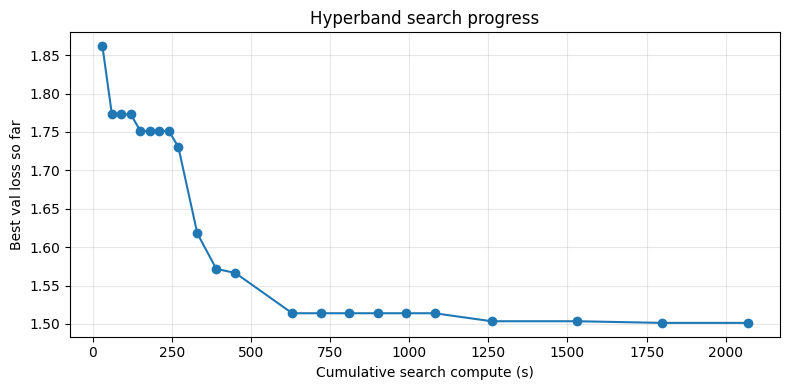

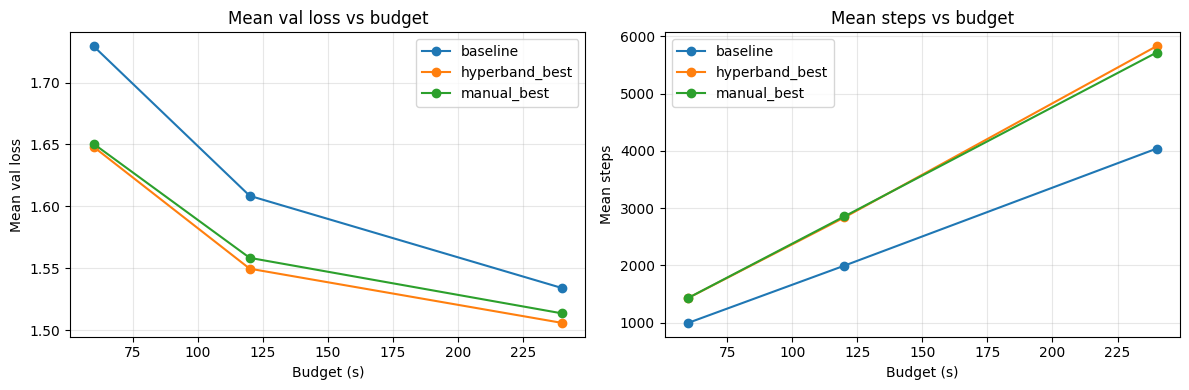

wrote: /content/comp560-niloy/autoresearch-tinyshakespeare/HYPERBAND_SUMMARY.md
# Hyperband Summary

Question:
- does Hyperband beat manual autoresearch sweep under same fixed compute budget?

Hyperband winner:
- run: `hb_s0_i0_661d4b697c`
- val loss: `1.5014`
- config: `{"batch_size":32,"block_size":128,"dropout":0.1,"eval_interval":400,"grad_clip":1.0,"learning_rate":0.003,"n_embd":160,"n_head":5,"n_layer":5,"weight_decay":0.01}`

Search progress:
- runs: `22`
- total staged compute: `2070s`
- best-so-far final val loss: `1.5014`

| Config | Budget (s) | Mean val loss | Std val loss | Mean tok/s | Mean steps |
|--------|------------|---------------|--------------|------------|------------|
| `baseline` | `60` | `1.7294` | `0.0031` | `67770.54` | `996.3` |
| `hyperband_best` | `60` | `1.6481` | `0.0178` | `97637.26` | `1430.7` |
| `manual_best` | `60` | `1.6505` | `0.0025` | `97735.45` | `1432.0` |
| `baseline` | `120` | `1.6085` | `0.0077` | `67924.33` | `1995.3` |
| `hyperband_best`

In [11]:
plot_best_so_far(all_rows)
plot_budget_comparison(summary_rows)

write_hyperband_summary(
    search_rows=all_rows,
    compare_rows=compare_rows,
    hyperband_best_config=hyperband_best_config,
    output_path=HYPERBAND_SUMMARY_PATH,
)

print("wrote:", HYPERBAND_SUMMARY_PATH)
print(HYPERBAND_SUMMARY_PATH.read_text(encoding="utf-8"))